# 🌧️ 손으로 익히는 미니 트랜스포머 — "하늘에 먹구름이 많아지면 뭐가 생각나?"

> ✍️ **자습 방법**: 이 노트북은 **직접 타이핑**하며 배웁니다. 각 단계마다
> ① 설명과 **입력할 코드**가 보이고 → ② 바로 아래 **빈 셀에 그대로 입력**하고 ▶ 실행하면 됩니다.
> 위에서 아래로 순서대로 진행하세요. ✅ 표시가 나오면 잘 된 것입니다.

> 🚀 **Colab에서 열기**: 이 `example.ipynb` 를 [Google Colab](https://colab.research.google.com) 에
> 업로드하거나, 저장소에 올린 뒤 `File ▸ Open notebook ▸ GitHub` 로 열면 됩니다.

트랜스포머의 핵심 직관을 한 문장으로 익힙니다 — 답 "**비**"를 만들려면 질문의 "**먹구름**"에 **주목**해야 합니다.
이게 바로 **어텐션**이 하는 일이에요. CPU로 수 초면 끝납니다(GPU 불필요).

## 0️⃣ 준비 — 라이브러리 & 한글 폰트

그래프에 한글이 깨지지 않도록 폰트를 설정하고, 필요한 도구를 불러옵니다.

**아래 코드를 직접 입력하고 ▶ 실행하세요:**

```python
!apt-get -qq -y install fonts-nanum > /dev/null 2>&1   # 그래프용 한글 폰트 (Colab)
import math, random, logging                            # 기본 도구
import torch                                            # 딥러닝 프레임워크
from torch import nn                                    # 신경망 부품
from torch.nn.utils.rnn import pad_sequence             # 길이 맞추기(패딩)
import matplotlib.pyplot as plt                         # 그래프
from matplotlib import font_manager                     # 폰트 관리

logging.getLogger("matplotlib.mathtext").setLevel(logging.ERROR)  # 사소한 폰트 경고 숨김
plt.rcParams["axes.unicode_minus"] = False                        # 마이너스 기호 깨짐 방지
try:
    font_manager.fontManager.addfont("/usr/share/fonts/truetype/nanum/NanumGothic.ttf")
    plt.rcParams["font.family"] = "NanumGothic"                   # Colab: 나눔고딕
except Exception:
    for _n in ["Malgun Gothic", "AppleGothic", "NanumGothic"]:    # 로컬 폴백
        if _n in {f.name for f in font_manager.fontManager.ttflist}:
            plt.rcParams["font.family"] = _n
            break
print("준비 완료! PyTorch", torch.__version__)
```

In [3]:
# 👆 위 코드를 그대로 입력한 뒤 ▶(Shift+Enter) 실행하세요
!apt-get -qq -y install fonts-nanum > /dev/null 2>&1
import math, random, logging
import torch
from torch import nn
from torch.nn.utils.rnn import pad_sequence
import matplotlib.pyplot as plt
from matplotlib import font_manager

logging.getLogger("matplotlib.mathtext").setLevel(logging.ERROR)
plt.rcParams["axes.unicode_minus"] = False
try:
    font_manager.fontManager.addfont("/usr/share/fonts/truetype/nanum/NanumGothic.ttf")
    plt.rcParams["font.family"] = "NanumGothic"
except Exception:
  for _n in ["Malgun Gothic", "AppleGothic", "NanumGothic"]:
      if _n in {f.name for f in font_manager.fontManager.ttflist}:
          plt.rcParams["font.family"] = _n
          break
print("준비 완료! PyTorch", torch.__version__)


준비 완료! PyTorch 2.11.0+cpu


## 1️⃣ 데이터 — 질문 → 답 6쌍

문장 틀은 **똑같이** 두고 **'대상' 단어만** 바꿉니다(먹구름/별/해/…). 그래야 답을 가르는
유일한 단서가 '대상'이 되어, 모델이 **반드시 그 단어에 주목**하게 됩니다.

질문→답 6쌍을 만듭니다.

**아래 코드를 직접 입력하고 ▶ 실행하세요:**

```python
DATA = [
    ("하늘에 먹구름이 보이면 뭐가 생각나", "비가 올 것 같아"),
    ("하늘에 별이 보이면 뭐가 생각나", "밤이 깊었나 봐"),
    ("하늘에 해가 보이면 뭐가 생각나", "아침이 밝았구나"),
    ("하늘에 무지개가 보이면 뭐가 생각나", "비가 그쳤나 봐"),
    ("하늘에 눈송이가 보이면 뭐가 생각나", "겨울이 왔구나"),
    ("하늘에 노을이 보이면 뭐가 생각나", "저녁이 되었네"),
]
for q, a in DATA[:3]:
    print(q, "→", a)
```

In [34]:
# 👆 위 코드를 그대로 입력한 뒤 ▶(Shift+Enter) 실행하세요
DATA = [
    ("하늘에 먹구름이 보이면 뭐가 생각나", "비가 올 것 같아"),
    ("하늘에 별이 보이면 뭐가 생각나", "밤이 깊었나 봐"),
    ("하늘에 해가 보이면 뭐가 생각나", "아침이 밝았구나"),
    ("하늘에 무지개가 보이면 뭐가 생각나", "비가 그쳤나 봐"),
    ("하늘에 눈송이가 보이면 뭐가 생각나", "겨울이 왔구나"),
    ("하늘에 노을이 보이면 뭐가 생각나", "저녁이 되었네"),
]
for q, a in DATA[:3]:
    print(q, "→", a)

하늘에 먹구름이 보이면 뭐가 생각나 → 비가 올 것 같아
하늘에 별이 보이면 뭐가 생각나 → 밤이 깊었나 봐
하늘에 해가 보이면 뭐가 생각나 → 아침이 밝았구나


In [6]:
assert len(DATA) == 6
print("✅ 데이터 OK")


✅ 데이터 OK


## 2️⃣ 토큰화 & 단어장

컴퓨터는 글자를 못 읽으니 **단어를 번호로** 바꿉니다. 문장을 공백으로 자르고(토큰화),
단어↔번호 사전(Vocab)을 만듭니다. `<pad>/<sos>/<eos>/<unk>` 는 특수 토큰이에요.

토큰화 함수와 단어장(Vocab) 클래스를 정의합니다.

**아래 코드를 직접 입력하고 ▶ 실행하세요:**

```python
PAD, SOS, EOS, UNK = "<pad>", "<sos>", "<eos>", "<unk>"   # 특수 토큰
SPECIALS = [PAD, SOS, EOS, UNK]

def tokenize(s):
    return s.strip().split()                    # 공백 단위로 자르기

class Vocab:
    def __init__(self, sentences):
        toks = sorted({t for s in sentences for t in tokenize(s)})
        self.itos = SPECIALS + toks             # 번호 → 단어
        self.stoi = {t: i for i, t in enumerate(self.itos)}   # 단어 → 번호
    def __len__(self):
        return len(self.itos)
    @property
    def pad_id(self):
        return self.stoi[PAD]
    @property
    def sos_id(self):
        return self.stoi[SOS]
    @property
    def eos_id(self):
        return self.stoi[EOS]
    def encode(self, s, add_special=True):
        ids = [self.stoi.get(t, self.stoi[UNK]) for t in tokenize(s)]
        return [self.sos_id] + ids + [self.eos_id] if add_special else ids
    def decode(self, ids):
        return " ".join(self.itos[i] for i in ids if self.itos[i] not in (PAD, SOS, EOS))
```

In [12]:
# 👆 위 코드를 그대로 입력한 뒤 ▶(Shift+Enter) 실행하세요
# 컴퓨터는 글자를 못 읽으니 '단어 → 번호' 사전(Vocab)을 만듭니다.
# 특수토큰 4종: <pad>=길이맞춤, <sos>=시작, <eos>=끝, <unk>=모르는 단어. 맨 앞에 둬 항상 0~3번 고정.
PAD, SOS, EOS, UNK = "<pad>", "<sos>", "<eos>", "<unk>"   # 특수 토큰
SPECIALS = [PAD, SOS, EOS, UNK]

def tokenize(s):
    return s.strip().split()                    # 토큰화: 공백 단위로 단어 쪼개기

class Vocab:                                     # 단어↔번호 양방향 사전 클래스
    def __init__(self, sentences):
        toks = sorted({t for s in sentences for t in tokenize(s)})  # 중복 제거 후 정렬(번호 고정=재현성)
        self.itos = SPECIALS + toks             # itos: 번호 → 단어 (특수토큰 뒤에 실제 단어)
        self.stoi = {t: i for i, t in enumerate(self.itos)}   # stoi: 단어 → 번호 (itos를 뒤집음)
    def __len__(self):
        return len(self.itos)                   # 전체 단어 수(=임베딩 행 개수)

    # 자주 쓰는 특수토큰 번호를 property로 편하게 꺼내 씀 (예: vocab.pad_id)
    @property
    def pad_id(self):
        return self.stoi[PAD]
    @property
    def sos_id(self):
        return self.stoi[SOS]
    @property
    def eos_id(self):
        return self.stoi[EOS]

    def encode(self, s, add_special=True):      # 문장 → 번호 리스트
        ids = [self.stoi.get(t, self.stoi[UNK]) for t in tokenize(s)]  # 모르는 단어는 <unk> 번호로
        return [self.sos_id] + ids + [self.eos_id] if add_special else ids  # 앞뒤에 <sos>…<eos> 붙임
    def decode(self, ids):                      # 번호 리스트 → 문장(특수토큰은 걸러냄)
        return "".join(self.itos[i] for i in ids if self.itos[i] not in (PAD, SOS, EOS))

질문용·답용 단어장을 각각 만듭니다.

**아래 코드를 직접 입력하고 ▶ 실행하세요:**

```python
src_vocab = Vocab([q for q, _ in DATA])         # 질문 단어장
tgt_vocab = Vocab([a for _, a in DATA])         # 답 단어장
print("질문 단어", len(src_vocab), "| 답 단어", len(tgt_vocab))
```

In [13]:
# 👆 위 코드를 그대로 입력한 뒤 ▶(Shift+Enter) 실행하세요
# 질문(source)과 답(target)은 쓰는 단어가 다르므로 단어장을 각각 따로 만듦
src_vocab = Vocab([q for q, _ in DATA])         # 질문 단어장 (튜플에서 q만 추출)
tgt_vocab = Vocab([a for _, a in DATA])         # 답 단어장 (튜플에서 a만 추출)

print("질문 단어", len(src_vocab), "| 답 단어", len(tgt_vocab))  # 크기 = 특수토큰 4 + 고유 단어 수

질문 단어 14 | 답 단어 18


In [14]:
# 체크포인트: 특수토큰 번호가 기대대로인지 확인(<pad>=0, <sos>=1)
assert src_vocab.pad_id == 0 and tgt_vocab.sos_id == 1
print("✅ 사전 OK")

✅ 사전 OK


## 3️⃣ 모델 부품 만들기

이제 트랜스포머의 부품을 하나씩 직접 만듭니다. **위치 인코딩 → 어텐션 → 멀티헤드 →
FFN → 인코더/디코더 블록 → 마스크 → 전체 조립** 순서예요. 조금 길지만, 손으로 치면 구조가 몸에 남습니다. 💪

**위치 인코딩** — 어텐션은 순서를 모릅니다. sin/cos 파도무늬로 '몇 번째 단어인지'를 심어 줍니다.

**아래 코드를 직접 입력하고 ▶ 실행하세요:**

```python
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=128, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe = torch.zeros(max_len, d_model)                      # 빈 표
        pos = torch.arange(0, max_len).float().unsqueeze(1)     # 위치 0,1,2,...
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)     # 짝수 차원 = sin
        pe[:, 1::2] = torch.cos(pos * div)     # 홀수 차원 = cos
        self.register_buffer("pe", pe.unsqueeze(0))
    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1)])   # 임베딩 + 위치 파도
```

In [57]:
# 👆 위 코드를 그대로 입력한 뒤 ▶(Shift+Enter) 실행하세요
# 위치 인코딩: 어텐션은 순서를 모르므로 sin/cos '파도무늬'로 '몇 번째 단어인지'를 심어 줌
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=128, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)                     # 위치정보를 더한 뒤 일부를 무작위로 0
        pe = torch.zeros(max_len, d_model)                     # 위치별 파도무늬가 들어갈 빈 표
        pos = torch.arange(0, max_len).float().unsqueeze(1)    # 위치 인덱스 0,1,2,... (세로)
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))  # 차원별 주파수
        pe[:, 0::2] = torch.sin(pos * div)                     # 짝수 차원 = sin
        pe[:, 1::2] = torch.cos(pos * div)                     # 홀수 차원 = cos
        self.register_buffer("pe", pe.unsqueeze(0))            # 학습 안 되는 상수로 등록, 배치축 추가

    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1)])        # 임베딩 + 문장 길이만큼 자른 위치 파도

**어텐션 핵심 공식** — 관련도 점수(QKᵀ/√d)를 softmax로 비율화해 V를 가중합합니다.

**아래 코드를 직접 입력하고 ▶ 실행하세요:**

```python
def scaled_dot_product_attention(q, k, v, mask=None, dropout=None):
    d_k = q.size(-1)
    scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(d_k)   # 관련도 점수
    if mask is not None:
        scores = scores.masked_fill(mask == 0, float("-inf"))        # 가릴 곳은 -무한대
    attn = torch.softmax(scores, dim=-1)                             # 합=1 비율로
    if dropout is not None:
        attn = dropout(attn)
    return torch.matmul(attn, v), attn                               # V를 비율대로 가중합
```

In [15]:
# 👆 위 코드를 그대로 입력한 뒤 ▶(Shift+Enter) 실행하세요
# 어텐션 핵심: 각 단어(Q)가 다른 단어(K)와 얼마나 관련 있나 점수화 → 비율(softmax)로 V를 가중합
def scaled_dot_product_attention(q, k, v, mask=None, dropout=None):
    d_k = q.size(-1)                                                 # 헤드 하나의 차원 수
    scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(d_k)   # 관련도 점수 Q·Kᵀ, √d_k로 스케일
    if mask is not None:
        scores = scores.masked_fill(mask == 0, float("-inf"))        # 가릴 곳은 -무한대(softmax에서 0이 됨)
    attn = torch.softmax(scores, dim=-1)                             # Key 방향 합=1인 비율로
    if dropout is not None:
        attn = dropout(attn)                                         # 일부 연결을 무작위로 끊음(정규화)
    return torch.matmul(attn, v), attn                               # V를 비율대로 가중합(attn은 시각화용)

In [16]:
# 체크포인트: 점수가 모두 같으면(여기선 전부 1) 두 Key에 0.5씩 균등 분배돼야 함
_c, _w = scaled_dot_product_attention(torch.ones(1, 1, 2, 4), torch.ones(1, 1, 2, 4),
                                      torch.arange(8.).reshape(1, 1, 2, 4))
assert torch.allclose(_w, torch.full((1, 1, 2, 2), 0.5))   # 점수가 같으면 0.5씩 균등
print("✅ 어텐션 공식 OK")

✅ 어텐션 공식 OK


**멀티헤드 어텐션** — 여러 관점(헤드)으로 나눠 동시에 주목하고 합칩니다.

**아래 코드를 직접 입력하고 ▶ 실행하세요:**

```python
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads, dropout=0.1):
        super().__init__()
        self.h, self.dk = num_heads, d_model // num_heads
        self.wq = nn.Linear(d_model, d_model); self.wk = nn.Linear(d_model, d_model)
        self.wv = nn.Linear(d_model, d_model); self.wo = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)
        self.last_attn_weights = None                 # 시각화용 보관
    def split(self, x):
        b, s, _ = x.shape
        return x.view(b, s, self.h, self.dk).transpose(1, 2)   # (B, 헤드, 길이, dk)
    def merge(self, x):
        b, _, s, _ = x.shape
        return x.transpose(1, 2).contiguous().view(b, s, self.h * self.dk)
    def forward(self, q, k, v, mask=None):
        q, k, v = self.split(self.wq(q)), self.split(self.wk(k)), self.split(self.wv(v))
        ctx, attn = scaled_dot_product_attention(q, k, v, mask, self.dropout)
        self.last_attn_weights = attn.detach()
        return self.wo(self.merge(ctx))
```

In [18]:
# 👆 위 코드를 그대로 입력한 뒤 ▶(Shift+Enter) 실행하세요
# 멀티헤드: 여러 관점(헤드)으로 나눠 동시에 주목한 뒤 합침
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads, dropout=0.1):
        super().__init__()
        self.h, self.dk = num_heads, d_model // num_heads       # h=헤드 수, dk=헤드당 차원
        self.wq = nn.Linear(d_model, d_model); self.wk = nn.Linear(d_model, d_model)  # Q·K 변환
        self.wv = nn.Linear(d_model, d_model); self.wo = nn.Linear(d_model, d_model)  # V 변환·출력 변환
        self.dropout = nn.Dropout(dropout)
        self.last_attn_weights = None                           # 히트맵용으로 어텐션 잠깐 보관
    def split(self, x):
        b, s, _ = x.shape
        return x.view(b, s, self.h, self.dk).transpose(1, 2)    # (B, 헤드, 길이, dk)로 쪼갬
    def merge(self, x):
        b, _, s, _ = x.shape
        return x.transpose(1, 2).contiguous().view(b, s, self.h * self.dk)  # 헤드들을 다시 합침
    def forward(self, q, k, v, mask=None):
        q, k, v = self.split(self.wq(q)), self. split(self.wk(k)), self.split(self.wv(v))  # 변환 후 헤드 분할
        ctx, attn = scaled_dot_product_attention(q, k, v, mask, self.dropout)  # 헤드별 어텐션
        self.last_attn_weights = attn.detach()                  # 시각화용 복사(계산그래프 분리)
        return self.wo(self.merge(ctx))                         # 헤드 합친 뒤 출력 변환

In [19]:
# 체크포인트: 멀티헤드가 입력 shape (1,3,8)을 그대로 돌려주는지(차원 보존) 확인
_m = MultiHeadAttention(8, 4, 0.0)
assert _m(torch.randn(1, 3, 8), torch.randn(1, 3, 8), torch.randn(1, 3, 8)).shape == (1, 3, 8)
print("✅ 멀티헤드 OK")

✅ 멀티헤드 OK


**FFN** — 각 단어를 혼자 더 깊이 곱씹는 작은 신경망입니다.

**아래 코드를 직접 입력하고 ▶ 실행하세요:**

```python
class PositionwiseFeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(d_model, d_ff), nn.ReLU(),
                                 nn.Dropout(dropout), nn.Linear(d_ff, d_model))
    def forward(self, x):
        return self.net(x)
```

In [20]:
# 👆 위 코드를 그대로 입력한 뒤 ▶(Shift+Enter) 실행하세요
# FFN: 각 단어를 혼자 더 깊이 곱씹는 작은 2층 신경망(모든 위치에 똑같이 적용)
class PositionwiseFeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(d_model, d_ff), nn.ReLU(),        # 차원 확대 → 비선형
                                 nn.Dropout(dropout), nn.Linear(d_ff, d_model))  # 드롭아웃 → 원래 차원 복귀

    def forward(self, x):
        return self.net(x)                          # (B, S, d_model) 그대로, 위치마다 독립 통과

**인코더 블록** — 셀프어텐션 → (원본 더하기+정규화) → FFN → (더하기+정규화).

**아래 코드를 직접 입력하고 ▶ 실행하세요:**

```python
class EncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.attn = MultiHeadAttention(d_model, num_heads, dropout)
        self.ffn = PositionwiseFeedForward(d_model, d_ff, dropout)
        self.n1 = nn.LayerNorm(d_model); self.n2 = nn.LayerNorm(d_model)
        self.drop = nn.Dropout(dropout)
    def forward(self, x, mask):
        x = self.n1(x + self.drop(self.attn(x, x, x, mask)))   # 잔차 + 정규화
        x = self.n2(x + self.drop(self.ffn(x)))
        return x
```

In [38]:
# 👆 위 코드를 그대로 입력한 뒤 ▶(Shift+Enter) 실행하세요
# 인코더 블록: 셀프어텐션 → (잔차+정규화) → FFN → (잔차+정규화). 질문을 이해하는 한 겹
class EncoderLayer(nn.Module):
  def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
      super().__init__()
      self.attn = MultiHeadAttention(d_model, num_heads, dropout)   # 셀프어텐션
      self.ffn = PositionwiseFeedForward(d_model, d_ff, dropout)
      self.n1 = nn.LayerNorm(d_model); self.n2 = nn.LayerNorm(d_model)  # 하위층 뒤 정규화 2개
      self.drop = nn.Dropout(dropout)

  def forward(self, x, mask):
      x = self.n1(x + self.drop(self.attn(x, x, x, mask)))   # 잔차(x+…) + 정규화, 셀프라 q=k=v=x
      x = self.n2(x + self.drop(self.ffn(x)))                # FFN에도 동일한 잔차+정규화
      return x

**디코더 블록** — 마스크드 셀프어텐션 → 크로스어텐션(질문 곁눈질) → FFN.

**아래 코드를 직접 입력하고 ▶ 실행하세요:**

```python
class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads, dropout)
        self.cross_attn = MultiHeadAttention(d_model, num_heads, dropout)
        self.ffn = PositionwiseFeedForward(d_model, d_ff, dropout)
        self.n1 = nn.LayerNorm(d_model); self.n2 = nn.LayerNorm(d_model); self.n3 = nn.LayerNorm(d_model)
        self.drop = nn.Dropout(dropout)
    def forward(self, x, enc, tgt_mask, src_mask):
        x = self.n1(x + self.drop(self.self_attn(x, x, x, tgt_mask)))       # 미래 가림
        x = self.n2(x + self.drop(self.cross_attn(x, enc, enc, src_mask)))  # 질문 곁눈질
        x = self.n3(x + self.drop(self.ffn(x)))
        return x
```

In [84]:
# 👆 위 코드를 그대로 입력한 뒤 ▶(Shift+Enter) 실행하세요
# 디코더 블록: 마스크드 셀프어텐션 → 크로스어텐션(질문 곁눈질) → FFN. 답을 생성하는 한 겹
class DecoderLayer(nn.Module):
  def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
    super().__init__()
    self.self_attn = MultiHeadAttention(d_model, num_heads, dropout)   # 지금까지의 답끼리 참조(미래는 가림)
    self.cross_attn = MultiHeadAttention(d_model, num_heads, dropout)  # 답(Q)이 질문(K,V)을 곁눈질
    self.ffn = PositionwiseFeedForward(d_model, d_ff, dropout)
    self.n1 = nn.LayerNorm(d_model); self.n2 = nn.LayerNorm(d_model); self.n3 = nn.LayerNorm(d_model)  # 하위층 3개→정규화 3개
    self.drop = nn.Dropout(dropout)

  def forward(self, x, enc, tft_mask, src_mask):
    x = self.n1(x + self.drop(self.self_attn(x, x, x, tft_mask)))       # ① 미래 단어 가림(정답 누설 방지)
    x = self.n2(x + self.drop(self.cross_attn(x, enc, enc, src_mask)))  # ② 인코딩된 질문(enc)을 참조
    x = self.n3(x + self.drop(self.ffn(x)))                            # ③ FFN, 세 층 모두 잔차+정규화
    return x

**인코더** — 임베딩+위치인코딩 후, 인코더 블록을 여러 겹 통과시켜 질문을 이해합니다.

**아래 코드를 직접 입력하고 ▶ 실행하세요:**

```python
class Encoder(nn.Module):
    def __init__(self, vocab, d_model, num_heads, num_layers, d_ff, dropout, max_len):
        super().__init__()
        self.d_model = d_model
        self.emb = nn.Embedding(vocab, d_model)
        self.pos = PositionalEncoding(d_model, max_len, dropout)
        self.layers = nn.ModuleList([EncoderLayer(d_model, num_heads, d_ff, dropout)
                                     for _ in range(num_layers)])
    def forward(self, src, mask):
        x = self.pos(self.emb(src) * math.sqrt(self.d_model))
        for l in self.layers:
            x = l(x, mask)
        return x
```

In [65]:
# 👆 위 코드를 그대로 입력한 뒤 ▶(Shift+Enter) 실행하세요
# 인코더: 임베딩+위치인코딩 후 인코더 블록을 여러 겹 통과시켜 질문을 이해
class Encoder(nn.Module):
    def __init__(self, vocab, d_model, num_heads, num_layers, d_ff, dropout, max_len):
        super().__init__()
        self.d_model = d_model                              # √d_model 스케일링에 사용
        self.emb = nn.Embedding(vocab, d_model)             # 단어 번호 → d_model 차원 벡터
        self.pos = PositionalEncoding(d_model, max_len, dropout)
        self.layers = nn.ModuleList([EncoderLayer(d_model, num_heads, d_ff, dropout)  # 블록 num_layers개 쌓기
                                      for _ in range(num_layers)])

    def forward(self, src, mask):
        x = self.pos(self.emb(src) * math.sqrt(self.d_model))  # 임베딩×√d_model + 위치인코딩
        for l in self.layers:
            x = l(x, mask)                                  # 블록을 순서대로 통과
        return x

**디코더** — 인코딩된 질문을 참고해 답을 만들 표현으로 바꿉니다.

**아래 코드를 직접 입력하고 ▶ 실행하세요:**

```python
class Decoder(nn.Module):
    def __init__(self, vocab, d_model, num_heads, num_layers, d_ff, dropout, max_len):
        super().__init__()
        self.d_model = d_model
        self.emb = nn.Embedding(vocab, d_model)
        self.pos = PositionalEncoding(d_model, max_len, dropout)
        self.layers = nn.ModuleList([DecoderLayer(d_model, num_heads, d_ff, dropout)
                                     for _ in range(num_layers)])
    def forward(self, tgt, enc, tgt_mask, src_mask):
        x = self.pos(self.emb(tgt) * math.sqrt(self.d_model))
        for l in self.layers:
            x = l(x, enc, tgt_mask, src_mask)
        return x
```

In [75]:
# 👆 위 코드를 그대로 입력한 뒤 ▶(Shift+Enter) 실행하세요
# 디코더: 인코더와 뼈대는 같되, 각 층에서 인코딩된 질문(enc)을 참고해 답 표현으로 변환
class Decoder(nn.Module):
  def __init__(self, vocab, d_model, num_heads, num_layers, d_ff, dropout, max_len):
      super().__init__()
      self.d_model = d_model
      self.emb = nn.Embedding(vocab, d_model)             # 답 단어장 임베딩(출력층과 가중치 공유 예정)
      self.pos = PositionalEncoding(d_model, max_len, dropout)
      self.layers = nn.ModuleList([DecoderLayer(d_model, num_heads, d_ff, dropout)  # 디코더 블록 쌓기
                                    for _ in range(num_layers)])

  def forward(self, tgt, enc, tgt_mask, src_mask):
      x = self.pos(self.emb(tgt) * math.sqrt(self.d_model))  # 임베딩×√d_model + 위치인코딩
      for l in self.layers:
          x = l(x, enc, tgt_mask, src_mask)               # 각 블록에 질문(enc)과 두 마스크 전달
      return x

**전체 조립** — 인코더+디코더+출력층. 출력층은 디코더 임베딩과 가중치를 공유(weight tying)합니다.

**아래 코드를 직접 입력하고 ▶ 실행하세요:**

```python
class Transformer(nn.Module):
    def __init__(self, src_vocab, tgt_vocab, d_model=64, num_heads=4,
                 num_layers=2, d_ff=256, dropout=0.1, max_len=32):
        super().__init__()
        self.encoder = Encoder(src_vocab, d_model, num_heads, num_layers, d_ff, dropout, max_len)
        self.decoder = Decoder(tgt_vocab, d_model, num_heads, num_layers, d_ff, dropout, max_len)
        self.out = nn.Linear(d_model, tgt_vocab, bias=False)
        self.out.weight = self.decoder.emb.weight     # weight tying(가중치 공유)
    def forward(self, src, tgt, src_mask, tgt_mask):
        return self.out(self.decoder(tgt, self.encoder(src, src_mask), tgt_mask, src_mask))
    def encode(self, src, src_mask):
        return self.encoder(src, src_mask)
    def decode_step(self, tgt, enc, tgt_mask, src_mask):
        return self.out(self.decoder(tgt, enc, tgt_mask, src_mask))
```

In [77]:
# 👆 위 코드를 그대로 입력한 뒤 ▶(Shift+Enter) 실행하세요
# 전체 조립: 인코더 + 디코더 + 출력층을 하나로 묶음
class Transformer(nn.Module):
    def __init__(self, src_vocab, tgt_vocab, d_model=64, num_heads=4,
                  num_layers=2, d_ff=256, dropout=0.1, max_len=32):   # 하이퍼파라미터 기본값
      super().__init__()
      self.encoder = Encoder(src_vocab, d_model, num_heads, num_layers, d_ff, dropout, max_len)  # 질문 이해
      self.decoder = Decoder(tgt_vocab, d_model, num_heads, num_layers, d_ff, dropout, max_len)  # 답 생성
      self.out = nn.Linear(d_model, tgt_vocab, bias=False)  # d_model → 답 단어수 점수(logit)
      self.out.weight = self.decoder.emb.weight             # weight tying: 출력층=디코더 임베딩 공유

    def forward(self, src, tgt, src_mask, tgt_mask):        # 학습용 전체 경로
        return self.out(self.decoder(tgt, self.encoder(src, src_mask), tgt_mask, src_mask))

    def encode(self, src, src_mask):                        # 추론용: 질문 인코딩만(한 번만 계산)
        return self.encoder(src, src_mask)

    def decode_step(self, tgt, enc, tgt_mask, src_mask):    # 추론용: 답을 한 단어씩 늘리며 호출
        return self.out(self.decoder(tgt, enc, tgt_mask, src_mask))

**마스크** — 패딩 자리를 가리고(padding), 미래 단어를 못 보게(causal) 합니다.

**아래 코드를 직접 입력하고 ▶ 실행하세요:**

```python
def make_padding_mask(seq, pad_id):
    return (seq != pad_id).unsqueeze(1).unsqueeze(2)              # 패딩 위치 가림
def make_causal_mask(seq_len, device):
    return torch.tril(torch.ones(seq_len, seq_len, device=device)).bool().unsqueeze(0).unsqueeze(0)
def make_decoder_mask(tgt, pad_id):
    return make_padding_mask(tgt, pad_id) & make_causal_mask(tgt.size(1), tgt.device)
```

In [82]:
# 👆 위 코드를 그대로 입력한 뒤 ▶(Shift+Enter) 실행하세요
# 마스크: '여기는 보지 마'라고 알려 주는 True/False 표
def make_padding_mask(seq, pad_id):
    return (seq != pad_id).unsqueeze(1).unsqueeze(2)          # 패딩(<pad>) 자리를 가림 → (B,1,1,S)
def make_causal_mask(seq_len, device):
    return torch.tril(torch.ones(seq_len, seq_len, device=device)).bool().unsqueeze(0).unsqueeze(0)  # 하삼각=미래 가림
def make_decoder_mask(tgt, pad_id):
    return make_padding_mask(tgt, pad_id) & make_causal_mask(tgt.size(1), tgt.device)  # 패딩 가림 AND 미래 가림

In [44]:
# 체크포인트: 3x3 인과 마스크의 True 개수가 1+2+3=6인지 확인(하삼각형 검증)
assert make_causal_mask(3, torch.device("cpu")).sum().item() == 6   # 1+2+3
print("✅ 마스크 OK")

✅ 마스크 OK


## 4️⃣ 학습 — "틀린 만큼 조금씩 고치기"

학습은 **(1) 예측 → (2) 정답과 비교해 loss 계산 → (3) loss만큼 가중치 수정** 의 반복입니다.
loss 숫자가 점점 0에 가까워지면 잘 배우는 중이에요.

질문/답을 번호 텐서로 바꾸고 길이를 맞추는 함수입니다.

**아래 코드를 직접 입력하고 ▶ 실행하세요:**

```python
def build_batches(pairs, sv, tv):
    src = [torch.tensor(sv.encode(q, add_special=False)) for q, _ in pairs]
    tgt = [torch.tensor(tv.encode(a, add_special=True)) for _, a in pairs]
    src = pad_sequence(src, batch_first=True, padding_value=sv.pad_id)   # 길이 맞추기
    tgt = pad_sequence(tgt, batch_first=True, padding_value=tv.pad_id)
    return src, tgt
```

In [45]:
# 👆 위 코드를 그대로 입력한 뒤 ▶(Shift+Enter) 실행하세요
# 배치 만들기: 문장들을 번호 텐서로 바꾸고 길이를 맞춰 하나의 직사각형 배치로 묶음
def build_batches(pairs, sv, tv):
    src = [torch.tensor(sv.encode(q, add_special=False)) for q, _ in pairs]  # 질문: 특수토큰 없이 인코딩
    tgt = [torch.tensor(tv.encode(a, add_special=True)) for _, a in pairs]   # 답: <sos>…<eos> 붙여 인코딩
    src = pad_sequence(src, batch_first=True, padding_value=sv.pad_id)   # 최대 길이에 맞춰 <pad>로 채움
    tgt = pad_sequence(tgt, batch_first=True, padding_value=tv.pad_id)

    return src, tgt

모델을 만들고 400번 학습합니다(수 초). loss가 쑥쑥 내려가는지 보세요.

**아래 코드를 직접 입력하고 ▶ 실행하세요:**

```python
torch.manual_seed(42)                                    # 재현성(같은 결과)
src_ids, tgt_ids = build_batches(DATA, src_vocab, tgt_vocab)
max_len = max(src_ids.size(1), tgt_ids.size(1), 20) + 2
model = Transformer(len(src_vocab), len(tgt_vocab), max_len=max_len)
opt = torch.optim.Adam(model.parameters(), lr=3e-4)
crit = nn.CrossEntropyLoss(ignore_index=tgt_vocab.pad_id)
dec_in, dec_tgt = tgt_ids[:, :-1], tgt_ids[:, 1:]        # 입력은 <sos>부터, 정답은 한 칸 뒤
src_mask = make_padding_mask(src_ids, src_vocab.pad_id)
model.train()
for ep in range(1, 401):
    tgt_mask = make_decoder_mask(dec_in, tgt_vocab.pad_id)
    logits = model(src_ids, dec_in, src_mask, tgt_mask)                    # (1) 예측
    loss = crit(logits.reshape(-1, logits.size(-1)), dec_tgt.reshape(-1))  # (2) 정답과 비교
    opt.zero_grad(); loss.backward(); opt.step()                          # (3) 가중치 수정
    if ep % 100 == 0 or ep == 1:
        print(f"epoch {ep:4d} | loss {loss.item():.4f}")
```

In [85]:
# 👆 위 코드를 그대로 입력한 뒤 ▶(Shift+Enter) 실행하세요
# 모델 만들고 학습: (1) 예측 → (2) loss 계산 → (3) 가중치 수정 을 400번 반복
torch.manual_seed(42)                                    # 재현성(같은 결과)
src_ids, tgt_ids = build_batches(DATA, src_vocab, tgt_vocab)          # 질문/답 배치 텐서 준비
max_len = max(src_ids.size(1), tgt_ids.size(1), 20) + 2              # 위치인코딩 표가 넉넉하도록 여유
model = Transformer(len(src_vocab), len(tgt_vocab), max_len=max_len)  # 단어장 크기로 모델 생성
opt = torch.optim.Adam(model.parameters(), lr=3e-4)                  # 옵티마이저(lr=한 걸음 크기)
crit = nn.CrossEntropyLoss(ignore_index=tgt_vocab.pad_id)           # 손실함수(<pad>는 제외)
dec_in, dec_tgt = tgt_ids[:, :-1], tgt_ids[:, 1:]        # 입력은 <sos>부터, 정답은 한 칸 뒤(티처 포싱)
src_mask = make_padding_mask(src_ids, src_vocab.pad_id)  # 질문 패딩 마스크(루프 밖에서 한 번만)
model.train()                                            # 학습 모드(드롭아웃 켜짐)

for ep in range(1, 401):
    tgt_mask = make_decoder_mask(dec_in, tgt_vocab.pad_id)                 # 미래+패딩 가림 마스크
    logits = model(src_ids, dec_in, src_mask, tgt_mask)                    # (1) 예측
    loss = crit(logits.reshape(-1, logits.size(-1)), dec_tgt.reshape(-1))  # (2) 정답과 비교
    opt.zero_grad(); loss.backward(); opt.step()                          # (3) 기울기 초기화→역전파→갱신
    if ep % 100 == 0 or ep == 1:
      print(f"epoch {ep:4d} | loss {loss.item(): .4f}")                   # loss가 내려가는지 확인

epoch    1 | loss  48.2067
epoch  100 | loss  1.9292
epoch  200 | loss  0.5854
epoch  300 | loss  0.0337
epoch  400 | loss  0.0034


In [ ]:
# 체크포인트: 학습이 충분히 됐는지 최종 loss가 0.5 미만인지 확인
assert loss.item() < 0.5
print("✅ 학습 완료! 최종 loss", round(loss.item(), 4))

## 5️⃣ 답 만들기 — 한 단어씩(마스킹)

답은 `<sos>`부터 **한 단어씩** 만듭니다. 다음 단어를 고를 땐 **앞말만** 볼 수 있어요(미래는 마스킹).
끝말잇기랑 비슷하죠!

질문을 받아 답을 greedy로 한 단어씩 생성하는 함수입니다(어텐션도 함께 뽑아 둠).

**아래 코드를 직접 입력하고 ▶ 실행하세요:**

```python
@torch.no_grad()
def answer(model, sv, tv, question, max_len=20):
    model.eval()
    src = torch.tensor([sv.encode(question, add_special=False)])
    src_mask = make_padding_mask(src, sv.pad_id)
    enc = model.encode(src, src_mask)
    gen, steps = [tv.sos_id], []
    for _ in range(max_len):
        tgt = torch.tensor([gen])
        tgt_mask = make_causal_mask(tgt.size(1), tgt.device)
        logits = model.decode_step(tgt, enc, tgt_mask, src_mask)
        nxt = logits[0, -1].argmax().item()               # 마지막 위치의 최고점 단어
        steps.append((tv.decode(gen), tv.itos[nxt]))
        gen.append(nxt)
        if nxt == tv.eos_id:
            break
    tgt = torch.tensor([gen]); tgt_mask = make_causal_mask(tgt.size(1), tgt.device)
    model.decode_step(tgt, enc, tgt_mask, src_mask)       # 어텐션 확보용 한 번 더
    cross = model.decoder.layers[-1].cross_attn.last_attn_weights[0].mean(0)
    return steps, tv.decode(gen), cross
```

In [92]:
# 👆 위 코드를 그대로 입력한 뒤 ▶(Shift+Enter) 실행하세요
# 답 생성: <sos>부터 한 단어씩(자기회귀), 매 스텝 최고점 단어를 고르는 greedy 방식
@torch.no_grad()                                 # 추론 중엔 기울기 계산 끔(메모리·속도 절약)
def answer(model, sv, tv, question, max_len=20):
  model.eval()                                   # 평가 모드(드롭아웃 꺼 결과 결정적)
  src = torch.tensor([sv.encode(question, add_special=False)])  # 질문을 번호 텐서로(배치축 추가)
  src_mask = make_padding_mask(src, sv.pad_id)
  enc = model.encode(src, src_mask)              # 질문 인코딩은 한 번만 하고 재사용
  gen, steps = [tv.sos_id], []                   # gen=지금까지 만든 답(<sos>로 시작), steps=과정 기록
  for _ in range(max_len):
      tgt = torch.tensor([gen])                  # 지금까지의 답을 텐서로
      tgt_mask = make_causal_mask(tgt.size(1), tgt.device)  # 추론엔 미래 가림 마스크만 필요
      logits = model.decode_step(tgt, enc, tgt_mask, src_mask)  # 다음 단어 점수 계산
      nxt = logits[0, -1].argmax().item()        # 마지막 위치의 최고점 단어 선택(greedy)
      steps.append((tv.decode(gen), tv.itos[nxt]))  # (지금까지 답, 새로 고른 단어) 기록
      gen.append(nxt)                            # 고른 단어를 답 뒤에 이어 붙임
      if nxt == tv.eos_id:
        break                                    # <eos>가 나오면 생성 종료

  tgt = torch.tensor([gen]); tgt_mask = make_causal_mask(tgt.size(1), tgt.device)
  model.decode_step(tgt, enc, tgt_mask, src_mask)  # 완성된 답으로 한 번 더 통과(어텐션 확보용)
  cross = model.decoder.layers[-1].cross_attn.last_attn_weights[0].mean(0)  # 마지막 층 크로스어텐션(헤드 평균)
  return steps, tv.decode(gen), cross            # (과정, 완성된 답, 크로스어텐션) 반환

먹구름 질문에 답해 보고, 한 단어씩 만들어지는 과정을 출력합니다.

**아래 코드를 직접 입력하고 ▶ 실행하세요:**

```python
q = "하늘에 먹구름이 보이면 뭐가 생각나"
steps, ans, cross = answer(model, src_vocab, tgt_vocab, q)
print("질문:", q)
for seen, nxt in steps:
    print(f"  '{seen or '<sos>'}'  →  {nxt}")
print("답:", ans)
```

In [93]:
# 👆 위 코드를 그대로 입력한 뒤 ▶(Shift+Enter) 실행하세요
# 먹구름 질문을 넣어 한 단어씩 만들어지는 과정을 확인
q = "하늘에 먹구름이 보이면 뭐가 생각나"
steps, ans, cross = answer(model, src_vocab, tgt_vocab, q)  # (과정, 답, 어텐션)
print("질문: ", q)
for seen, nxt in steps:
  print(f". '{seen or '<sos>'}' -> {nxt}")       # 지금까지의 답 → 새로 고른 단어

print("답: ", ans)

질문:  하늘에 먹구름이 보이면 뭐가 생각나
. '<sos>' -> 비가
. '비가' -> 올
. '비가올' -> 것
. '비가올것' -> 같아
. '비가올것같아' -> <eos>
답:  비가올것같아


## 6️⃣ 어텐션 히트맵 — 답이 어디에 주목했나?

이제 핵심! 답의 각 단어가 **질문의 어느 단어를 봤는지** 색으로 봅니다.
'먹구름이' 열이 가장 **밝으면** 성공 — 모델이 먹구름에 주목해 '비'를 떠올린 거예요. 🌧️

답 토큰이 질문 토큰에 준 어텐션을 히트맵으로 그립니다.

**아래 코드를 직접 입력하고 ▶ 실행하세요:**

```python
def show_attention(question, answer_text, cross):
    qs, ans_toks = tokenize(question), tokenize(answer_text)
    w = cross[:len(ans_toks), :len(qs)].numpy()
    plt.figure(figsize=(1.1 * len(qs) + 1, 0.7 * len(ans_toks) + 1))
    plt.imshow(w, aspect="auto", cmap="viridis")
    plt.xticks(range(len(qs)), qs, rotation=30, ha="right")
    plt.yticks(range(len(ans_toks)), ans_toks)
    plt.xlabel("질문 토큰"); plt.ylabel("생성한 답 토큰")
    plt.title(f"'{answer_text}' 이(가) 주목한 곳")
    plt.colorbar(); plt.tight_layout(); plt.show()
```

In [101]:
# 👆 위 코드를 그대로 입력한 뒤 ▶(Shift+Enter) 실행하세요
# 어텐션 히트맵: 답의 각 단어가 질문의 어느 단어에 주목했는지 색으로 표시(밝을수록 크게 주목)
def show_attention(question, answer_text, cross):
    qs, ans_toks = tokenize(question), tokenize(answer_text)  # 축 눈금에 쓸 질문/답 토큰
    w = cross[:len(ans_toks), :len(qs)].numpy()              # 실제 토큰 개수만큼 잘라 numpy로
    plt.figure(figsize=(1.1 * len(qs) + 1, 0.7 * len(ans_toks) + 1))  # 토큰 수에 비례한 그림 크기
    plt.imshow(w, aspect="auto", cmap="viridis")            # 가중치 행렬을 색 그리드로(보라~노랑)
    plt.xticks(range(len(qs)), qs, rotation=30, ha="right")  # x축=질문 토큰(30도 회전)
    plt.yticks(range(len(ans_toks)), ans_toks)              # y축=생성한 답 토큰
    plt.xlabel("질문 토큰"); plt.ylabel("생성한 답 토큰")
    plt.title(f"'{answer_text}' 이(가) 주목한 곳")
    plt.colorbar(); plt.tight_layout(); plt.show()          # 색막대·여백 정리 후 출력

히트맵을 그려 봅니다. '먹구름이' 열이 환하게 빛나면 성공!

**아래 코드를 직접 입력하고 ▶ 실행하세요:**

```python
show_attention(q, ans, cross)
```

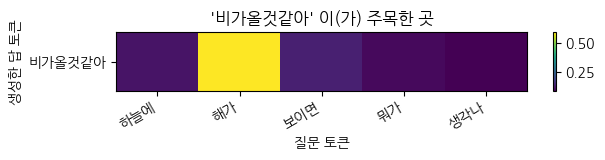

In [102]:
# 👆 위 코드를 그대로 입력한 뒤 ▶(Shift+Enter) 실행하세요
# '먹구름이' 열이 가장 환하면 모델이 그 단어에 주목해 '비'를 떠올린 것!
show_attention(q, ans, cross)

## 7️⃣ 대조 — 키워드가 바뀌면 답도 바뀐다

문장 틀은 똑같은데 '대상' 단어만 바꾸면, 모델이 주목하는 곳이 옮겨가고 답도 달라집니다.

세 가지 질문에 답해 보고 비교합니다.

**아래 코드를 직접 입력하고 ▶ 실행하세요:**

```python
for q in ["하늘에 먹구름이 보이면 뭐가 생각나",
          "하늘에 별이 보이면 뭐가 생각나",
          "하늘에 해가 보이면 뭐가 생각나"]:
    _, a, _ = answer(model, src_vocab, tgt_vocab, q)
    print(f"{tokenize(q)[1]:<6} → {a}")
```

In [100]:
# 👆 위 코드를 그대로 입력한 뒤 ▶(Shift+Enter) 실행하세요
# 대조: 문장 틀은 그대로 두고 '대상' 단어만 바꾸면 주목하는 곳이 옮겨가고 답도 달라짐
for q in ["하늘에 먹구름이 보이면 뭐가 생각나",
          "하늘에 별이 보이면 뭐가 생각나",
          "하늘에 해가 보이면 뭐가 생각나"]:
    _, a, _ = answer(model, src_vocab, tgt_vocab, q)  # 답만 필요하므로 steps·cross는 버림
    print(f"{tokenize(q)[1]:<6} → {a}")               # 질문의 두 번째 토큰(=바뀌는 대상) → 답

먹구름이   → 비가올것같아
별이     → 밤이깊었나봐
해가     → 아침이밝았구나


## 8️⃣ 정리 & 다음 단계 🎉

수고했어요! 방금 여러분은 트랜스포머를 **손으로 직접 만들어** 봤습니다.

- **어텐션** = 답을 만들 때 중요한 단어(먹구름)에 **밑줄 긋기**
- **마스킹 디코딩** = 답을 **한 단어씩**, 미래는 못 보고 만들기
- **크로스 어텐션** = 답을 쓰는 내내 **질문을 곁눈질**

➡️ 다음은 본 과제 **한국어→영어 번역 미니 트랜스포머**입니다. 구조는 똑같고,
**질문→답**이 **한국어→영어**로 바뀔 뿐이에요. 여기서 익힌 감각으로 바로 도전해 보세요!